In [1]:
import os
import sys
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
from mpl_toolkits.mplot3d import Axes3D

from tqdm.notebook import tqdm

sys.path.append("/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/training/models")
from Binary_classification import Binary_classification_2 as model

In [2]:
weight_path = "/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/training/save_dir/control_experiment-FGN_01100-03000_val-FGN03100~03300_upgrade-model.pth"
weight_para = torch.load(weight_path, map_location=torch.device('cpu'))

In [3]:
model = model(latent=100, input_depth=30, input_height=100, input_width=100)
model.load_state_dict(weight_para)

<All keys matched successfully>

In [4]:
# ==========================================
# 4. 3D Grad-CAM++ のクラス定義（前述のものを流用）
# ==========================================
class GradCAMPlusPlus3D:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.hook_handles = []
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output): self.activations = output
        def backward_hook(module, grad_input, grad_output): self.gradients = grad_output[0]
        self.hook_handles.append(self.target_layer.register_forward_hook(forward_hook))
        self.hook_handles.append(self.target_layer.register_backward_hook(backward_hook))

    def generate_cam(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = torch.argmax(output, dim=1).item()
        
        self.model.zero_grad()
        # score = output[0, class_idx]
        score = output[0, 0]
        score.backward()

        # フックから特徴量と勾配を取得
        activations = self.activations.detach()
        gradients = self.gradients.detach()

        # 勾配の1乗、2乗、3乗を計算
        grads_power_1 = gradients
        grads_power_2 = gradients ** 2
        grads_power_3 = gradients ** 3

        # =================================================================
        # 修正箇所: 3D Grad-CAM++ の重み (alpha) 計算
        # =================================================================
        # 空間次元 (2, 3, 4) の sum を集約せず、各ボクセルの activations を直接使用します
        aij = 2 * grads_power_2
        bijk = grads_power_3 * activations  
        
        # 分母の打ち消し合いと0除算を防ぐため、絶対値と微小値を適用
        denominator = torch.abs(aij + bijk) + 1e-10

        # 各ボクセル位置 [i, j, k] ごとの alpha を計算
        alpha = grads_power_2 / denominator
        
        # alpha と正の勾配（ReLU）を掛け合わせ、最後に空間次元 (Depth, Height, Width) で総和
        weights = alpha * torch.clamp(grads_power_1, min=0)
        weights = torch.sum(weights, dim=(2, 3, 4), keepdim=True)  # [Batch, Channel, 1, 1, 1]

        # =================================================================
        # 後半の処理（重み付けと正規化）
        # =================================================================
        # 各チャンネルの特徴マップに重みを掛けて足し合わせる
        cam = torch.sum(weights * activations, dim=1, keepdim=True)
        cam = torch.clamp(cam, min=0)  # 負の影響をカット
        
        # 0〜1 の範囲に正規化
        cam_min, cam_max = cam.min(), cam.max()
        if cam_min != cam_max:
            cam = (cam - cam_min) / (cam_max - cam_min)
        
        return cam.squeeze().cpu().numpy(), class_idx
    def remove_hooks(self):
        for handle in self.hook_handles: handle.remove()

In [5]:
def load_and_sample_data(region_dict, is_bubble=False, bubble_filename="slide_bubble_data.npy", train_name=None):
    all_selected_data = []
    # 領域ごとのカウントを保持するリストを別途作成
    counts_per_reg = []
    # 領域ごとのランダムインデックスを保持するリスト
    indices_list = []

    for reg, num_to_sample in tqdm(region_dict.items()):
        combined_region_data = None
        
        if is_bubble:
            region_data_list = []
            ranks = bubble_config.get(reg, [])
            for rank in ranks:
                path = f"{base_path}/{reg}/Rank_Bubble/{rank}/{bubble_filename}"
                if os.path.exists(path):
                    region_data_list.append(np.load(path))
                else:
                    print(f"Info: No data for {reg} {rank}. Skipping append.")
            if region_data_list:
                combined_region_data = np.concatenate(region_data_list)
        else:
            path = f"{base_path}/{reg}/thresh_up_low/lower-1.66_data.npy"
            if os.path.exists(path):
                combined_region_data = np.load(path)

        # --- サンプリング処理 ---
        if combined_region_data is not None and len(combined_region_data) > 0:
            current_size = len(combined_region_data)
            actual_sample_size = min(num_to_sample, current_size)
            indices = np.random.choice(current_size, size=actual_sample_size, replace=False)
            indices.sort()

            if not is_bubble:
                # 潜在変数解析のためにランダムインデックスの保存
                save_index_path = f"/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/training/training_data_indices/{reg}"
                Path(save_index_path).mkdir(parents=True, exist_ok=True)
                np.save(f"{save_index_path}/{train_name}", indices)
                indices_list.append(indices)

            sampled = combined_region_data[indices]
            all_selected_data.append(sampled) # データがある時だけリストに入れる
            counts_per_reg.append(len(sampled)) # 実際のサンプル数を記録
        else:
            # データがない場合はリストに追加せず、カウントだけ 0 にする
            counts_per_reg.append(0)

    if is_bubble:
        # データのリスト, 個数のリスト, インデックス番号
        return all_selected_data, counts_per_reg
    else:
        return np.concatenate(all_selected_data) if all_selected_data else np.array([]), indices_list


def reload_trainig_data(region_dict, data_type):
    all_selected_data = []
    # 領域ごとのカウントを保持するリストを別途作成
    counts_per_reg = []

    for reg, num_to_sample in tqdm(region_dict.items()):
        combined_region_data = None

        path = f"{base_path}/{reg}/thresh_up_low/lower-1.66_data.npy"
        if os.path.exists(path):
            combined_region_data = np.load(path)

        
        # --- サンプリング処理 ---
        if combined_region_data is not None and len(combined_region_data) > 0:
            if data_type == "training":
                random_indices_path = f"/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/training/training_data_indices/{reg}/control_experiment-FGN_01100-03000_val-FGN03100~03300_upgrage-model.npy"
            elif data_type == "test":
                random_indices_path = f"/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/training/training_data_indices/{reg}/control_experiment-FGN_01100-01500_val-FGN03100~03300_test_upgrade-model.npy"
            indices = np.load(random_indices_path)
            sampled = combined_region_data[indices]
            all_selected_data.append(sampled) # データがある時だけリストに入れる
            counts_per_reg.append(len(sampled)) # 実際のサンプル数を記録
        else:
            # データがない場合はリストに追加せず、カウントだけ 0 にする
            counts_per_reg.append(0)

    return np.concatenate(all_selected_data) if all_selected_data else np.array([]), counts_per_reg


def load_bubble_data(region_dict, bubble_filename="slide_bubble_data.npy"):
    all_selected_data = []
    # 領域ごとのカウントを保持するリストを別途作成
    counts_per_reg = []

    for reg, num_to_sample in tqdm(region_dict.items()):
        combined_region_data = None
        
        region_data_list = []
        ranks = bubble_config.get(reg, [])
        for rank in ranks:
            path = f"{base_path}/{reg}/Rank_Bubble/{rank}/{bubble_filename}"
            if os.path.exists(path):
                region_data_list.append(np.load(path))
            else:
                print(f"Info: No data for {reg} {rank}. Skipping append.")
        if region_data_list:
            combined_region_data = np.concatenate(region_data_list)

        if combined_region_data is not None and len(combined_region_data) > 0:
            all_selected_data.append(combined_region_data) # データがある時だけリストに入れる
            counts_per_reg.append(len(combined_region_data)) # 実際のサンプル数を記録
        else:
            # データがない場合はリストに追加せず、カウントだけ 0 にする
            counts_per_reg.append(0)

    # データのリスト, 個数のリスト, インデックス番号
    return all_selected_data, counts_per_reg

In [6]:
# テストpath
fits_path = "/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/fits/Galaxy_Plane/FUGIN/12CO/FGN_03300+0000_2x2_12CO_v1.00_cube.fits"

# 基本設定
base_path = "/home/cygnus/fujimoto/Cygnus-X_Molecular_Cloud_Analysis/Binary_classification/data/FUGIN/processed_data"

bubble_config = {
    # "FGN_03100+0000": ["Rank1", "Rank2", "Rank3"],
    # "FGN_03200+0000": ["Rank1", "Rank2", "Rank3"],
    # "FGN_03300+0000": ["Rank1", "Rank2", "Rank3"],
    "FGN_03400+0000": ["Rank1", "Rank2", "Rank3"],
    "FGN_03500+0000": ["Rank1", "Rank2", "Rank3"],
}

In [7]:
# 2. 検証データのロード
# 特定の数だけ欲しい場合はここで指定
test_request = {"FGN_03400+0000": 150,
                "FGN_03500+0000": 150}
test_bubble, count_ = load_and_sample_data(test_request, is_bubble=True, bubble_filename="bubble_data.npy")
test_bubble = np.concatenate(test_bubble)
print(count_)

  0%|          | 0/2 [00:00<?, ?it/s]

[28, 18]


In [8]:
pos_neg = 1

for key, count in zip(test_request.keys(), count_):
    test_request[key] = count * pos_neg
print(test_request)

{'FGN_03400+0000': 28, 'FGN_03500+0000': 18}


In [9]:
first_test = False
if first_test:
    test_no_bubbe, _ = load_and_sample_data(test_request, is_bubble=False, train_name="control_experiment-FGN_01100-01500_val-FGN03100~03300_test_upgrade-model.npy")
else:
    test_no_bubbe, _ = reload_trainig_data(test_request, data_type="test")

  0%|          | 0/2 [00:00<?, ?it/s]

In [10]:
class DataSet():
    def __init__(self, data, label):
        self.label = label
        self.data = data
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        return self.data[index], self.label[index]

In [11]:
# 3. ラベル付け
test_bubble_label = [1] * len(test_bubble)
test_data_label = [0] * len(test_no_bubbe)

In [12]:
test_data = np.concatenate((test_bubble, test_no_bubbe))
test_label = np.concatenate((test_bubble_label, test_data_label))

In [13]:
test_dataset = DataSet(test_data, test_label)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [14]:
print(model.features[-2])

Conv3d(32, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1))


In [15]:
class ModelWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        # フックの対象となる特徴マップ層を直接参照できるように紐付ける
        self.features = model.features

    def forward(self, x):
        out, _ = self.model(x)  # latent_out は捨てる
        return out

In [16]:
wrapped_model = ModelWrapper(model)

In [17]:
# ==========================================
# 5. 可視化処理（3D立体プロットとラベル名の追加）
# ==========================================
# テストデータから1件抽出
data_iter = iter(test_dataloader)
img_tensor, label_tensor = next(data_iter)
img_tensor = img_tensor.unsqueeze(0).float()

# Grad-CAM++の適用
cam_generator = GradCAMPlusPlus3D(wrapped_model, wrapped_model.features[-5])
print(wrapped_model.features[-12])
heatmap_low_res, pred_class = cam_generator.generate_cam(img_tensor, label_tensor)
cam_generator.remove_hooks()

# 低解像度の特徴マップを元の画像サイズ（28x28x28）に拡大
input_img = img_tensor.squeeze().numpy() # [28, 28, 28]
print(input_img.shape, heatmap_low_res.shape)
zoom_factors = [i / j for i, j in zip(input_img.shape, heatmap_low_res.shape)]
print(zoom_factors)
heatmap_resized = zoom(heatmap_low_res, zoom_factors, order=1)
print(heatmap_resized.shape)

# --- 【追加】予測されたクラスインデックスから実際のラベル名を取得 ---
# info['label'] のキーは文字列の数字（'0', '1'..）になっているため str(pred_class) とします
# print(str(pred_class.item()))
pred_class =str(pred_class.item())
target_label_name = str(pred_class)

Conv3d(16, 32, kernel_size=(4, 4, 4), stride=(2, 2, 2), padding=(1, 1, 1))
(30, 100, 100) (3, 12, 12)
[10.0, 8.333333333333334, 8.333333333333334]
(30, 100, 100)


/usr/local/lib/python3.10/dist-packages/torch/nn/modules/module.py:1866: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


In [18]:
print(input_img.shape)

(30, 100, 100)


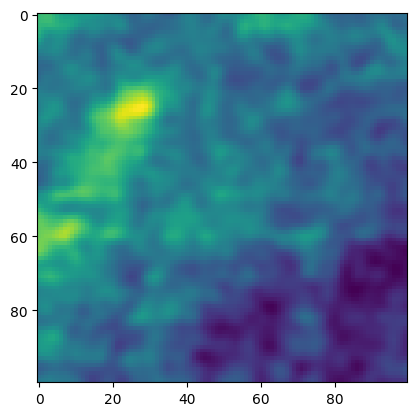

In [19]:
plt.imshow(np.sum(input_img, axis=0))

0.0 0.0


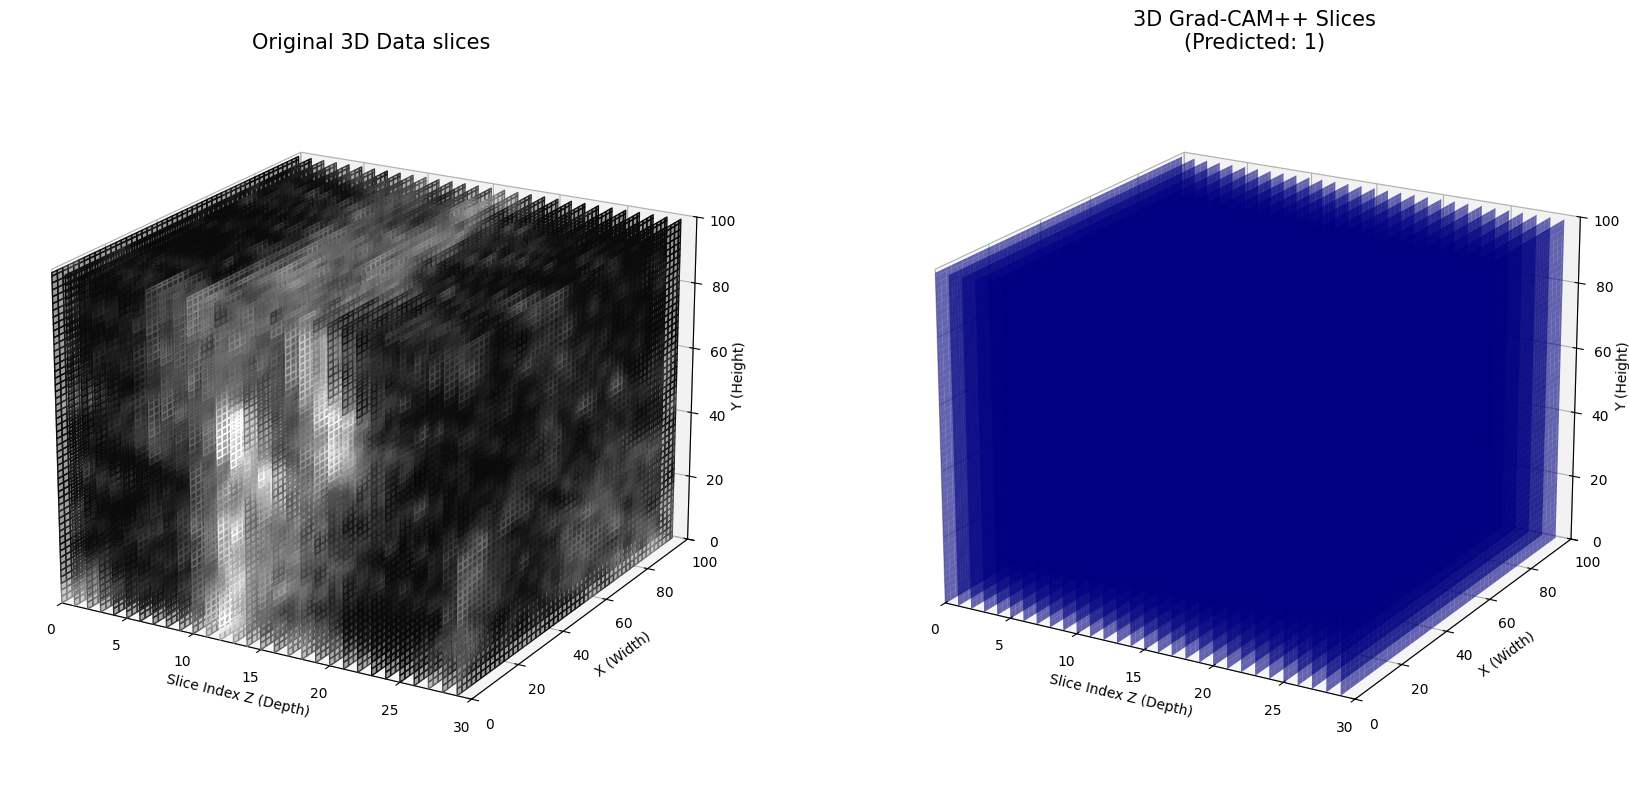

In [22]:
from mpl_toolkits.mplot3d import Axes3D

# --- 設定 ---
# 30枚の中から何枚おきに表示するか（1ならすべて、2なら1枚おき）
slice_step = 1  # 枚数が多いと描画が重くなるため、2〜3に間引くと見やすくなります
slice_indices = range(0, 30, slice_step)

# 100x100のメッシュグリッドを、Y軸（奥行き）とZ軸（高さ）に対して作成
Y_mesh, Z_mesh = np.meshgrid(np.arange(100), np.arange(100))

# --- プロットの開始 ---
fig = plt.figure(figsize=(18, 8))

# -----------------------------------------------------------------
# 1. 元の3D画像（スライスプロット）
# -----------------------------------------------------------------
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.set_title(f"Original 3D Data slices", fontsize=15)

# 元データ用のカラーマップ（白黒画像なら 'gray' などが適しています）
orig_cmap = plt.get_cmap('gray')

for x_idx in slice_indices:
    X = np.ones_like(Y_mesh) * x_idx
    
    # 該当スライスのデータ取得
    slice_orig = input_img[x_idx, :, :]
    
    # 強度データをRGB(A)に変換
    # ※もし元データの値が 0-1 に正規化されていない場合は、事前に正規化するか
    #   orig_cmap((slice_orig - slice_orig.min()) / (slice_orig.max() - slice_orig.min())) としてください
    colors_orig = orig_cmap(slice_orig)
    
    # 垂直面にプロット
    ax1.plot_surface(X, Y_mesh, Z_mesh, facecolors=colors_orig, 
                     rstride=2, cstride=2, shade=False, alpha=0.4)

# 軸範囲・ラベル設定
ax1.set_xlim(0, 30)
ax1.set_ylim(0, 100)
ax1.set_zlim(0, 100)
ax1.set_xlabel('Slice Index Z (Depth)')
ax1.set_ylabel('X (Width)')
ax1.set_zlabel('Y (Height)', labelpad=0)
ax1.view_init(elev=20, azim=-60)

# -----------------------------------------------------------------
# 2. Grad-CAM++ 3D ヒートマップ（スライスプロット）
# -----------------------------------------------------------------
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.set_title(f"3D Grad-CAM++ Slices\n(Predicted: {target_label_name})", fontsize=15)

cam_cmap = plt.get_cmap('jet')

# --- 【追加】ヒートマップの値を 0.0 ~ 1.0 に正規化 ---
# ゼロ除算を防ぐため、最大値と最小値に差がある場合のみ処理します
cam_min = heatmap_resized.min()
cam_max = heatmap_resized.max()
print(cam_min, cam_max)
if cam_max - cam_min > 0:
    heatmap_normalized = (heatmap_resized - cam_min) / (cam_max - cam_min)
else:
    heatmap_normalized = heatmap_resized - cam_min # すべて0の配列にする
# ---------------------------------------------------

for x_idx in slice_indices:
    X = np.ones_like(Y_mesh) * x_idx

    # 正規化したデータから該当スライスを取得
    slice_cam = heatmap_normalized[x_idx, :, :]

    # カラーマップを適用（0.0 ~ 1.0 になったので正しく色がつきます）
    colors_cam = cam_cmap(slice_cam)

    # 注目度が低いボクセル（例: 上位80%に入らない、値が0.2未満の領域）を透明化
    # 正規化したことで、この閾値判定（0.2）も正しく機能するようになります
    low_confidence = slice_cam < 0.2  
    colors_cam[low_confidence, 3] = 0.0 # アルファチャンネルを0（透明）にする

    # 垂直面にプロット
    ax2.plot_surface(X, Y_mesh, Z_mesh, facecolors=colors_cam, 
                     rstride=2, cstride=2, shade=False, alpha=0.6)

# 軸範囲・ラベル設定
ax2.set_xlim(0, 30)
ax2.set_ylim(0, 100)
ax2.set_zlim(0, 100)
ax2.set_xlabel('Slice Index Z (Depth)')
ax2.set_ylabel('X (Width)')
ax2.set_zlabel('Y (Height)', labelpad=0)
ax2.view_init(elev=20, azim=-60)

plt.tight_layout()
plt.savefig("FGN_cloud_3D_CAM.png")
plt.show()